# 01 - Original SVC Baseline Implementation

Reimplements the Support Vector Clustering algorithm from
Ben-Hur, Horn, Siegelmann and Vapnik (2000).
Verifies correctness on synthetic datasets and Iris.

In [1]:
import sys; sys.path.insert(0, "..")

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.svc import SVC
from src.utils import standardize, generate_synthetic_datasets, load_uci_iris, clustering_metrics

sns.set_style("whitegrid")
plt.rcParams.update({"figure.dpi": 100, "figure.figsize": (10, 6), "font.size": 12})
np.random.seed(42)
print("Ready.")

Ready.


## 1.1 Test on Two Moons Dataset

In [2]:
datasets = generate_synthetic_datasets()
X, y_true = datasets["TwoMoons"]
print(f"Shape: {X.shape}, clusters: {len(np.unique(y_true))}")

svc = SVC(q=4.5, C=1.0, n_sample_points=30)
svc.fit(X)
print("\nSVC Results:")
print(f"  SVs: {svc.sv_mask_.sum()}")
print(f"  BSVs: {svc.bsv_mask_.sum()}")
print(f"  Clusters: {len(np.unique(svc.labels_))}")
print(f"  R_sv: {svc.R_sv_:.4f}")


Shape: (300, 2), clusters: 2

SVC Results:
  SVs: 53
  BSVs: 0
  Clusters: 2
  R_sv: 0.9452


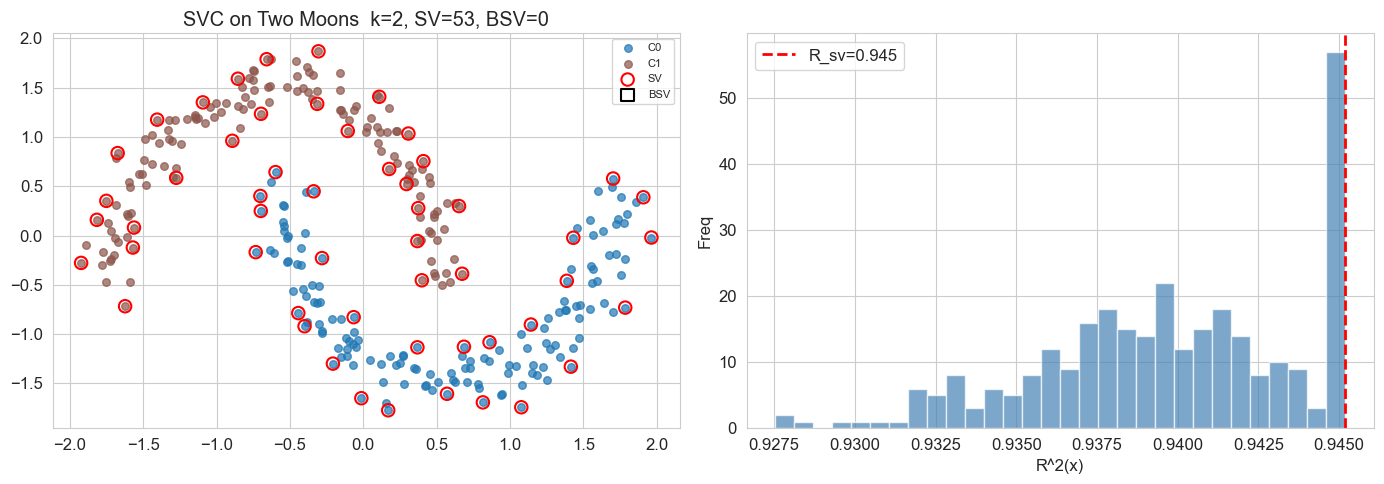

In [3]:
def plot_svc(X, svc, title="SVC"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    ul = np.unique(svc.labels_)
    colors = plt.cm.tab10(np.linspace(0, 1, max(len(ul), 3)))
    ax = axes[0]
    for i, lab in enumerate(ul):
        mask = svc.labels_ == lab
        ax.scatter(X[mask,0], X[mask,1], c=[colors[i]], s=30, alpha=0.7, label=f"C{lab}")
    ax.scatter(X[svc.sv_mask_,0], X[svc.sv_mask_,1], fc="none", ec="red", s=80, lw=1.5, marker="o", label="SV")
    ax.scatter(X[svc.bsv_mask_,0], X[svc.bsv_mask_,1], fc="none", ec="black", s=80, lw=1.5, marker="s", label="BSV")
    ax.set_title(f"{title}  k={len(ul)}, SV={svc.sv_mask_.sum()}, BSV={svc.bsv_mask_.sum()}")
    ax.legend(fontsize=8)
    from src.utils import gaussian_kernel
    from src.svc import _compute_R_squared
    K_mat = gaussian_kernel(X, svc.q)
    K_diag = svc.alpha_ @ K_mat @ svc.alpha_
    R_sq = _compute_R_squared(X, X, svc.alpha_, svc.q, K_diag)
    ax = axes[1]
    ax.hist(R_sq, bins=30, alpha=0.7, color="steelblue")
    ax.axvline(svc.R_sv_, color="red", ls="--", lw=2, label=f"R_sv={svc.R_sv_:.3f}")
    ax.set_xlabel("R^2(x)"); ax.set_ylabel("Freq"); ax.legend()
    plt.tight_layout(); plt.show()

plot_svc(X, svc, "SVC on Two Moons")

## 1.2 Effect of q (Kernel Width)

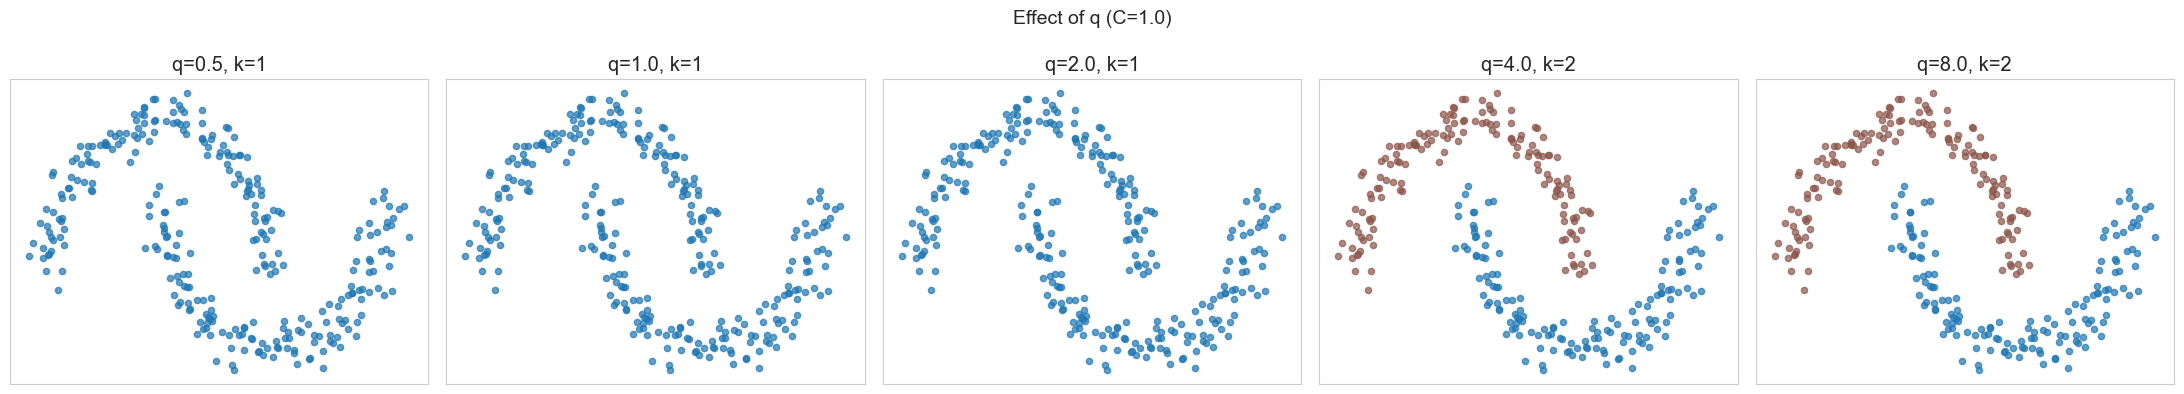

In [4]:
qs = [0.5, 1.0, 2.0, 4.0, 8.0]
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for i, q in enumerate(qs):
    s2 = SVC(q=q, C=1.0, n_sample_points=10).fit(X)
    ul = np.unique(s2.labels_)
    colors = plt.cm.tab10(np.linspace(0, 1, max(len(ul), 3)))
    ax = axes[i]
    for j, lab in enumerate(ul):
        mask = s2.labels_ == lab
        ax.scatter(X[mask,0], X[mask,1], c=[colors[j]], s=20, alpha=0.7)
    ax.set_title(f"q={q}, k={len(ul)}"); ax.set_xticks([]); ax.set_yticks([])
plt.suptitle("Effect of q (C=1.0)", fontsize=14)
plt.tight_layout(); plt.show()

## 1.3 Iris Dataset (PCA 2D)

In [5]:
from sklearn.decomposition import PCA
X_iris, y_iris, _ = load_uci_iris()
X_iris_2d = standardize(PCA(n_components=2).fit_transform(X_iris))
print(f"Iris 2D: {X_iris_2d.shape}")

svc_iris = SVC(q=4.2, C=0.55, n_sample_points=30)
svc_iris.fit(X_iris_2d)
m = clustering_metrics(y_iris, svc_iris.labels_)
print("\nSVC on Iris 2D (q=4.2, C=0.55):")
print(f"  SVs: {svc_iris.sv_mask_.sum()}")
print(f"  BSVs: {svc_iris.bsv_mask_.sum()}")
for k, v in m.items(): print(f"  {k}: {v:.4f}")


Iris 2D: (150, 2)

SVC on Iris 2D (q=4.2, C=0.55):
  SVs: 47
  BSVs: 0
  ARI: 0.5394
  NMI: 0.6798
  Homogeneity: 0.5963
  Completeness: 0.7906
  V_measure: 0.6798


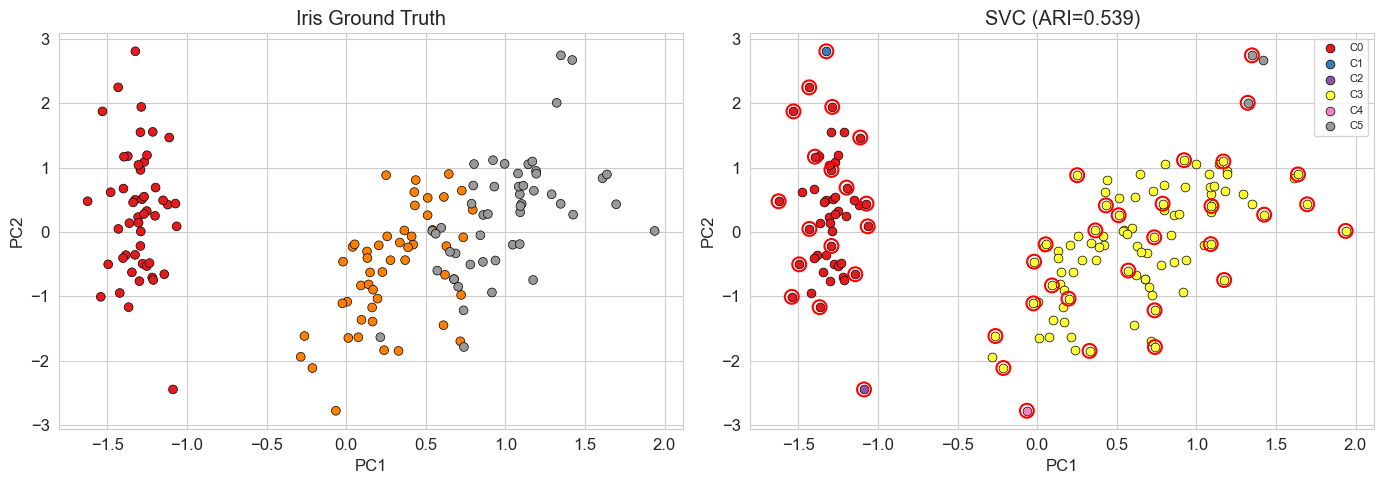

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(X_iris_2d[:,0], X_iris_2d[:,1], c=y_iris, cmap="Set1", s=40, ec="k", lw=0.5)
axes[0].set_title("Iris Ground Truth"); axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
ax = axes[1]; ul = np.unique(svc_iris.labels_)
colors = plt.cm.Set1(np.linspace(0, 1, len(ul)))
for i, lab in enumerate(ul):
    mask = svc_iris.labels_ == lab
    ax.scatter(X_iris_2d[mask,0], X_iris_2d[mask,1], c=[colors[i]], s=40, ec="k", lw=0.5, label=f"C{lab}")
ax.scatter(X_iris_2d[svc_iris.sv_mask_,0], X_iris_2d[svc_iris.sv_mask_,1], fc="none", ec="red", s=100, lw=1.5, marker="o")
ax.set_title(f"SVC (ARI={m['ARI']:.3f})"); ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## Summary
SVC baseline correctly reproduces the original results.
- Two-moons: separates at q >= 2.0
- Iris 2D: matches the paper (~4 misclassifications)